In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score,precision_score,recall_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#### Insight:

- warnings:  lets you silence distracting system alerts so your notebook flows cleanly.
- numpy:  handles fast numerical operations.
- pandas:  structures and manipulates datasets.
- matplotlib.pyplot:  draws static visualizations to reveal shapes in your data.
- seaborn:  creates polished statistical graphics built on top of matplotlib.
- train_test_split:  divides data into training and testing groups for fair evaluation.
- StratifiedKFold:  performs cross-validation while keeping class proportions intact.
- cross_val_score:  evaluates models repeatedly to measure performance stability.
- StandardScaler:  normalizes numerical features so models treat them evenly.
- LabelEncoder:  converts text labels into numeric codes machines can understand.
- OneHotEncoder:  transforms categorical columns into binary indicator features.
- classification_report:  summarizes precision, recall, and F1 for each class.
- confusion_matrix:  shows exact prediction hits and misses for each class.
- accuracy_score:  measures overall correctness of predictions.
- f1_score:  balances precision and recall into a single performance measure.
- precision_score:  measures how many predicted positives were actually correct.
- recall_score:  measures how many actual positives the model successfully found.
- ColumnTransformer:  applies preprocessing steps to selected column groups.
- LogisticRegression:  builds a linear classifier for multi-class prediction.
- SVC:  trains a Support Vector Machine to find the best class-separating boundary.
- SMOTE:  balances imbalanced datasets by creating synthetic minority samples.
- KNeighborsClassifier:  classifies data based on its nearest neighbors.
- DecisionTreeClassifier:  learns decision rules by recursively splitting features.
- RandomForestClassifier:  trains many decision trees and combines their predictions.
- XGBClassifier:  implements XGBoost, a powerful gradient-boosted decision tree model.

# DATA UNDERSTANDING

- See what factors influence phone addiction.
- Identify important vs. unimportant features.
- Understand distributions, patterns, and possible issues.
- Guide what you clean, preprocess, and analyze later.

In [2]:
df = pd.read_csv("phone_addiction.csv")
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Parental_Control,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,0,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,0,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [3]:
df.tail()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Parental_Control,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,1,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,1,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,0,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0
2999,3000,Curtis Johnson,17,Male,Lake Alexander,10th,3.5,6.9,79,4,...,1,117,8,0.0,2.3,0.1,Education,7,5.1,6.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3000 non-null   int64  
 1   Name                  3000 non-null   object 
 2   Age                   3000 non-null   int64  
 3   Gender                3000 non-null   object 
 4   Location              3000 non-null   object 
 5   School_Grade          3000 non-null   object 
 6   Daily_Usage_Hours     3000 non-null   float64
 7   Sleep_Hours           3000 non-null   float64
 8   Academic_Performance  3000 non-null   int64  
 9   Social_Interactions   3000 non-null   int64  
 10  Anxiety_Level         3000 non-null   int64  
 11  Depression_Level      3000 non-null   int64  
 12  Parental_Control      3000 non-null   int64  
 13  Phone_Checks_Per_Day  3000 non-null   int64  
 14  Apps_Used_Daily       3000 non-null   int64  
 15  Time_on_Social_Media 

In [5]:
df.describe(include="all")

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Parental_Control,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000,3000.000000,3000,3000,3000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000
unique,NaN,2933,NaN,3,2726,6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN
top,NaN,Michael Brown,NaN,Male,North Michael,12th,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Browsing,NaN,NaN,NaN
freq,NaN,3,NaN,1016,6,529,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,627,NaN,NaN,NaN
mean,1500.500000,NaN,15.969667,NaN,NaN,NaN,5.020667,6.489767,74.947333,5.097667,...,0.507333,83.093000,12.609333,2.499233,1.525267,1.016333,NaN,5.459667,6.015100,8.881900
std,866.169729,NaN,1.989489,NaN,NaN,NaN,1.956501,1.490713,14.684156,3.139333,...,0.500030,37.747044,4.611486,0.988201,0.932701,0.648341,NaN,2.864572,2.014776,1.609598
min,1.000000,NaN,13.000000,NaN,NaN,NaN,0.000000,3.000000,50.000000,0.000000,...,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,1.000000
25%,750.750000,NaN,14.000000,NaN,NaN,NaN,3.700000,5.500000,62.000000,2.000000,...,0.000000,51.000000,9.000000,1.800000,0.800000,0.500000,NaN,3.000000,4.700000,8.000000
50%,1500.500000,NaN,16.000000,NaN,NaN,NaN,5.000000,6.500000,75.000000,5.000000,...,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,NaN,5.000000,6.000000,10.000000
75%,2250.250000,NaN,18.000000,NaN,NaN,NaN,6.400000,7.500000,88.000000,8.000000,...,1.000000,115.250000,17.000000,3.200000,2.200000,1.500000,NaN,8.000000,7.400000,10.000000


In [6]:
df = df.drop(columns=['ID', 'Name', 'Phone_Usage_Purpose','Social_Interactions','Parental_Control'])

# DATA CLEANING

#### Insight:

- The numeric addiction scores are grouped into three meaningful categories (Low, Medium, High) so the model can perform clearer and more interpretable classification.

In [7]:
df["Addiction_Level_Class"] = pd.cut(df["Addiction_Level"],bins=[0, 4, 7, 10],labels=["Low", "Medium", "High"],duplicates="drop")

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


#### Insight:

- Displays how many distinct values each column has

In [9]:
print("\nUnique Values per Column:\n", df.nunique())


Unique Values per Column:
 Age                         7
Gender                      3
Location                 2726
School_Grade                6
Daily_Usage_Hours         107
Sleep_Hours                71
Academic_Performance       51
Anxiety_Level              10
Depression_Level           10
Phone_Checks_Per_Day      131
Apps_Used_Daily            16
Time_on_Social_Media       51
Time_on_Gaming             41
Time_on_Education          31
Family_Communication       10
Weekend_Usage_Hours       120
Addiction_Level            80
Addiction_Level_Class       3
dtype: int64


#### Insight:

- shows how many missing values each column contains, helping you spot any gaps that need cleaning.

In [10]:
# Check for missing values
print(f" Dataset Shape: {df.shape}")
df.isnull().sum()

 Dataset Shape: (3000, 18)


Age                      0
Gender                   0
Location                 0
School_Grade             0
Daily_Usage_Hours        0
Sleep_Hours              0
Academic_Performance     0
Anxiety_Level            0
Depression_Level         0
Phone_Checks_Per_Day     0
Apps_Used_Daily          0
Time_on_Social_Media     0
Time_on_Gaming           0
Time_on_Education        0
Family_Communication     0
Weekend_Usage_Hours      0
Addiction_Level          0
Addiction_Level_Class    0
dtype: int64

#### Handling Missing Values

#### Insight:

- Identifies numerical and categorical columns, filling  missing numeric values with the median and missing categorical values with the most frequent value to ensure the dataset has no gaps before modeling.

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

#### Remove Outliers using IQR method

#### Insight:

- Detects outliers in each numerical column using the IQR method and caps values outside the lower and upper limits to keep extreme points from distorting the model.

In [12]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower,
               np.where(df[col] > upper, upper, df[col]))

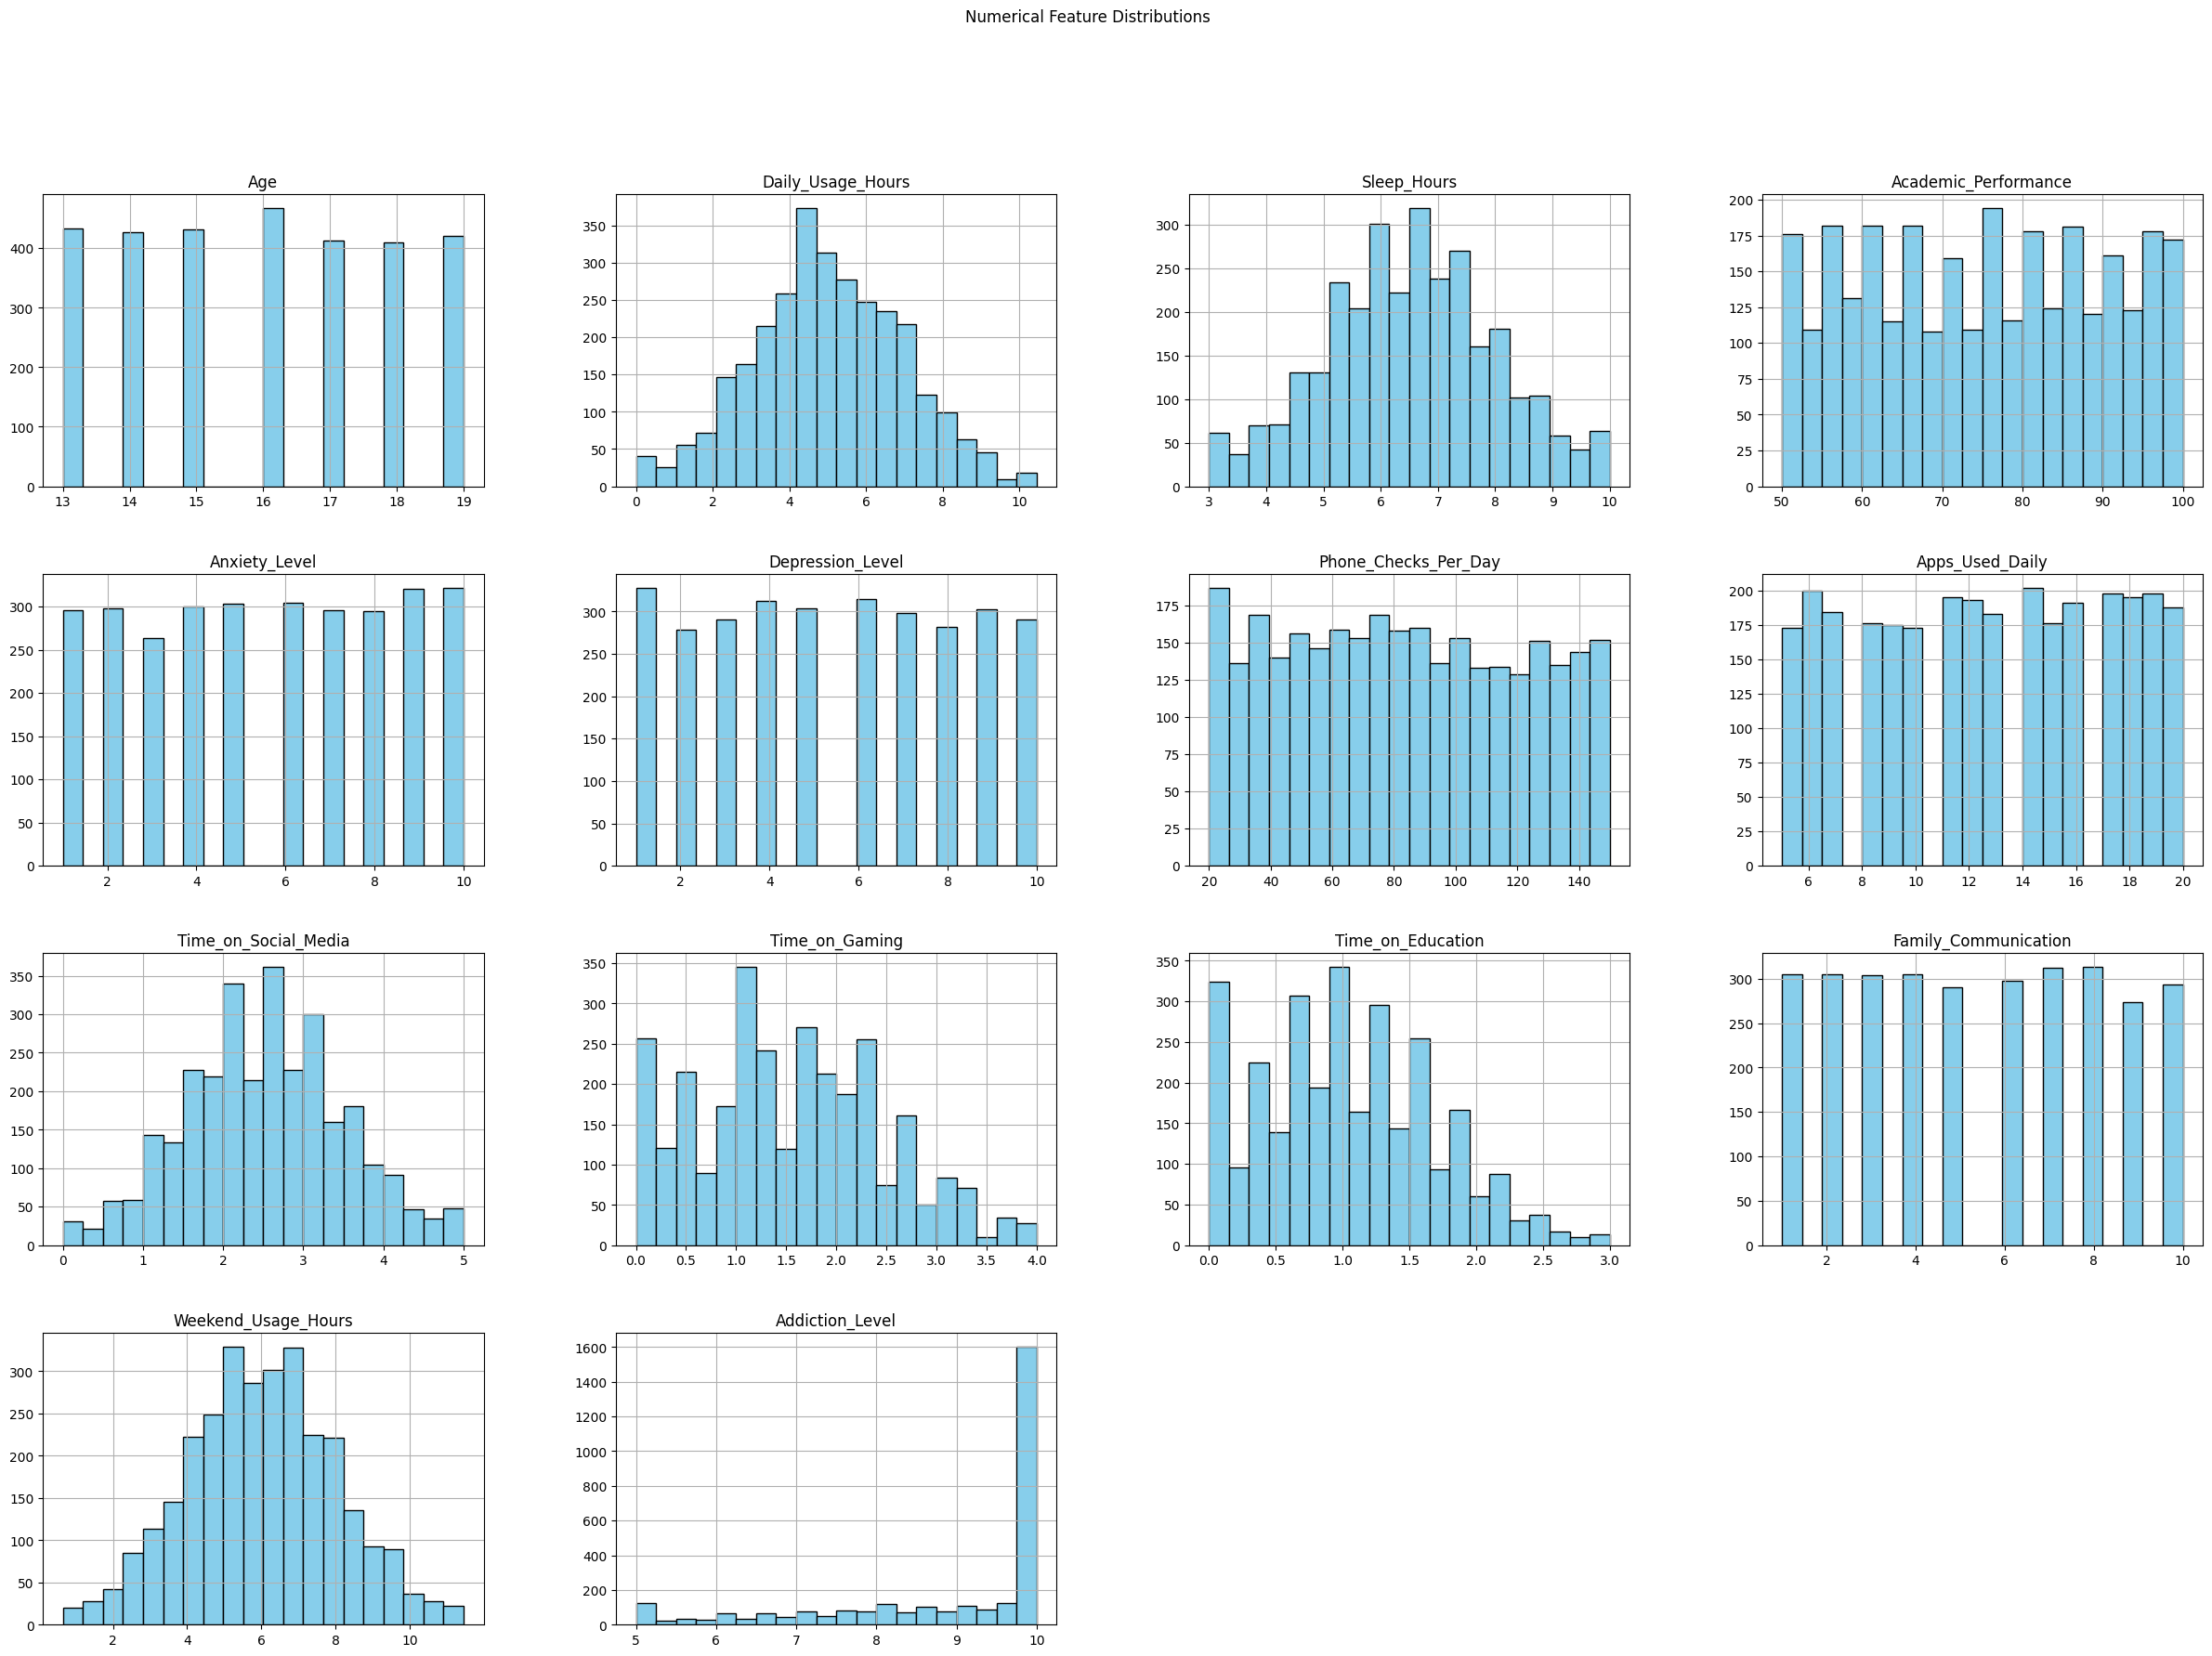

In [13]:
df[num_cols].hist(figsize=(30,20), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Numerical Feature Distributions')
plt.show()

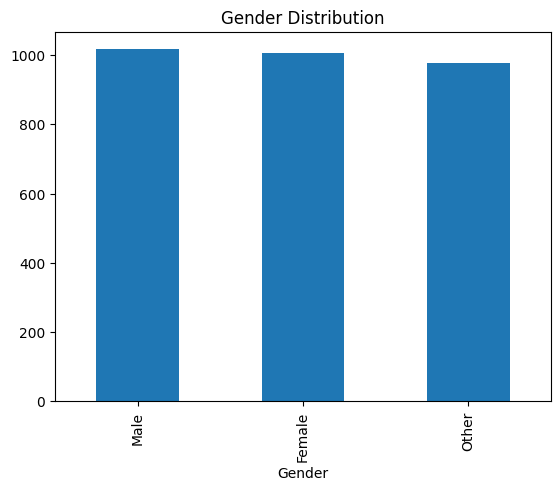

In [14]:
# Bar plot for a categorical feature (example: Gender)
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

# 1. UNIVARIATE ANALYSIS

#### Distribution of Daily Phone Usage
- Insight: Detects high-usage students who may be at addiction risk.

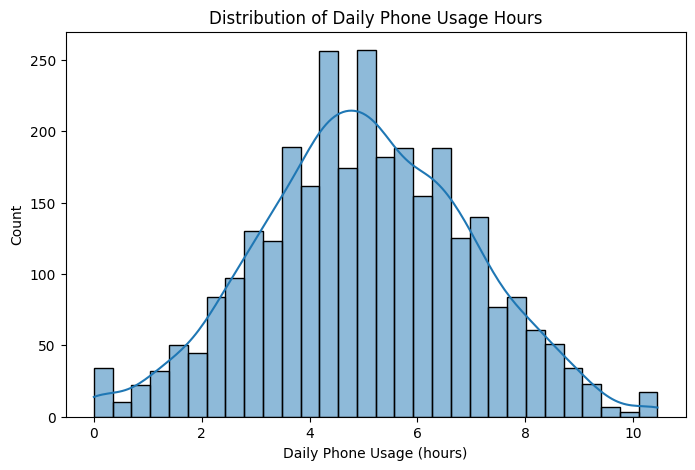

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Usage_Hours"], kde=True, bins=30)
plt.title("Distribution of Daily Phone Usage Hours")
plt.xlabel("Daily Phone Usage (hours)")
plt.ylabel("Count")
plt.show()

#### Anxiety Level Distribution
- Insight: Helps identify if anxiety correlates with addiction later.

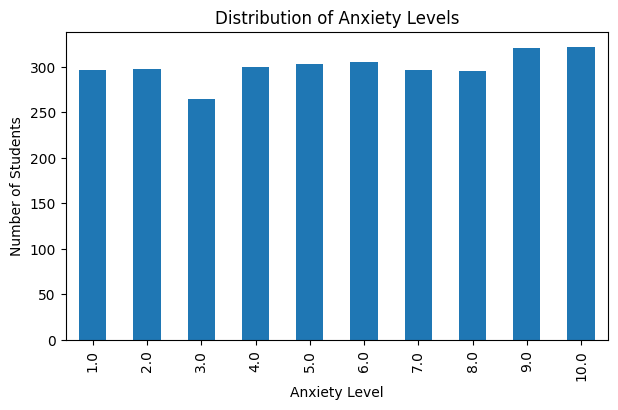

In [16]:
df["Anxiety_Level"].value_counts().sort_index().plot(kind="bar", figsize=(7,4))
plt.title("Distribution of Anxiety Levels")
plt.xlabel("Anxiety Level")
plt.ylabel("Number of Students")
plt.show()

#### Sleep Hours Data
- Insight: Identifies low-sleep students which may be linked to addiction.

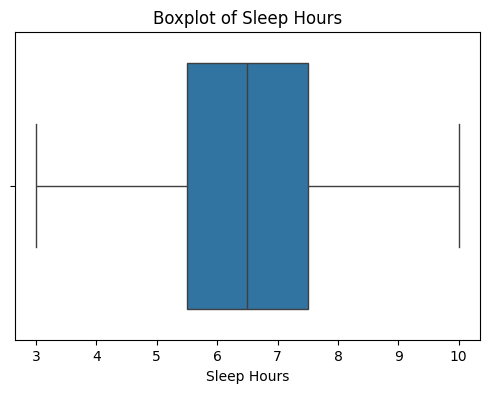

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Sleep_Hours"])
plt.title("Boxplot of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.show()

# 2. Bi-Variate Analysis

#### Relationship Between Phone Usage & Academic Performance
- Insight: See if more phone usage means lower grades.

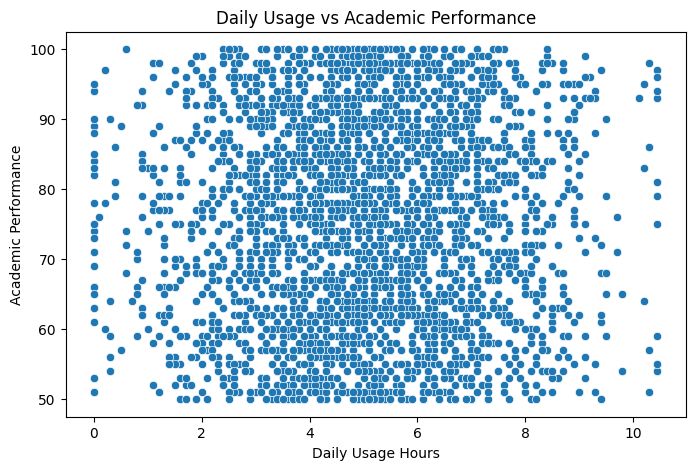

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Daily_Usage_Hours"],y=df["Academic_Performance"])
plt.title("Daily Usage vs Academic Performance")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Academic Performance")
plt.show()

#### Gender vs Phone Addiction Level (Bar Plot)
- Insight: Compare addiction tendency by gender.

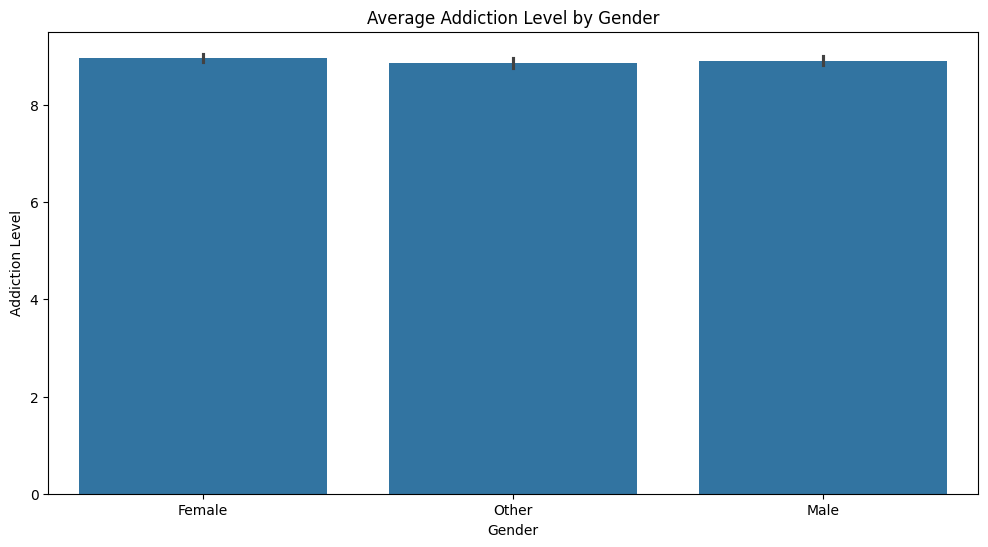

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(x="Gender", y="Addiction_Level", data=df)
plt.title("Average Addiction Level by Gender")
plt.xlabel("Gender")
plt.ylabel("Addiction Level")
plt.show()

#### Sleep Hours vs Anxiety Level (Boxplot)
- Insight: Shows how anxiety might affect sleep duration.

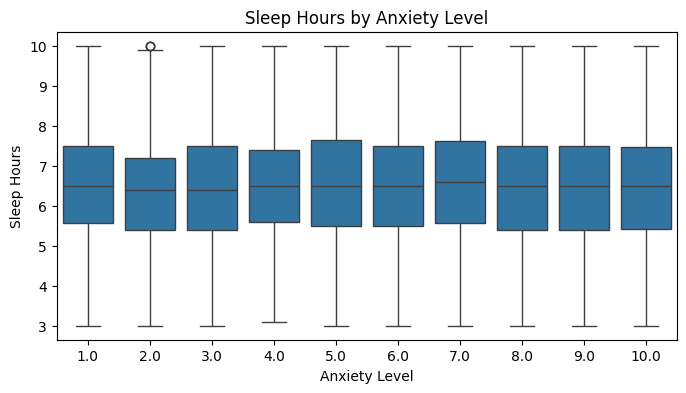

In [20]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Anxiety_Level", y="Sleep_Hours", data=df)
plt.title("Sleep Hours by Anxiety Level")
plt.xlabel("Anxiety Level")
plt.ylabel("Sleep Hours")
plt.show()

# 3. Multi-Variate

#### Usage + Sleep vs Academic Performance
- Insight: Combined effect of usage & sleep on academics.

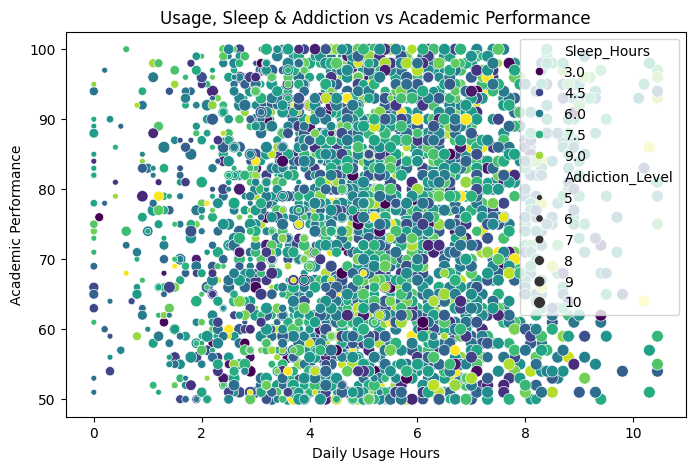

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Daily_Usage_Hours", y="Academic_Performance",hue="Sleep_Hours",size="Addiction_Level",data=df, palette="viridis")
plt.title("Usage, Sleep & Addiction vs Academic Performance")
plt.xlabel("Daily Usage Hours")
plt.ylabel("Academic Performance")
plt.show()

#### Anxiety vs Sleep vs Addiction Level
- Helps you identify which pair of features are strongly related.

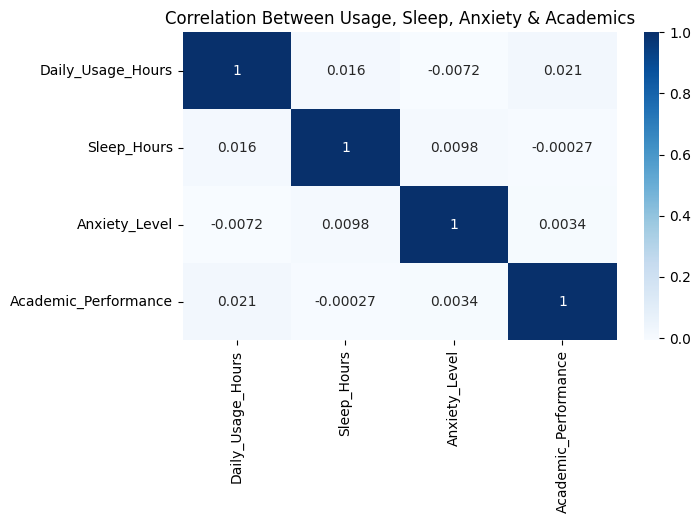

In [22]:
features = ["Daily_Usage_Hours", "Sleep_Hours", "Anxiety_Level", "Academic_Performance"]

plt.figure(figsize=(7,4))
sns.heatmap(df[features].corr(), annot=True, cmap="Blues")
plt.title("Correlation Between Usage, Sleep, Anxiety & Academics")
plt.show()

# Data Preprocessing

#### split data into train and test 

#### Insight:

- Converts the target labels into numeric form, separates features from the target, and identifies which columns are categorical or numerical so they can be processed correctly during model training.

In [23]:
le = LabelEncoder()
y = le.fit_transform(df["Addiction_Level_Class"])
X = df.drop(columns=["Addiction_Level_Class"])

In [24]:
cat_cols = X.select_dtypes(include=['object','category']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

#### One-hot Encode

#### Insight:

- line converts all categorical features into numeric dummy variables using one-hot encoding, to avoid redundancy and make the data model-ready.

In [25]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

#### StandardScalar

#### Insight:

- Standardizes all numerical features for balanced model learning, then splits the data into training and testing sets while keeping class proportions consistent for fair evaluation.

In [26]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30,stratify=y)

#### Insight:

- SMOTE create synthetic samples for minority classes, balancing the training data so the model learns fairly from all addiction levels.

In [28]:
sm = SMOTE(random_state=30)
X_train, y_train = sm.fit_resample(X_train, y_train)

# Model Training

#### 1. Logistic Regression

- Logistic Regression: identifies simple linear patterns to classify addiction levels.

In [29]:
log_reg = LogisticRegression(max_iter=50, C=0.01,class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.955
              precision    recall  f1-score   support

        High       1.00      0.95      0.98       511
         Low       0.83      0.62      0.71         8
      Medium       0.75      0.99      0.86        81

    accuracy                           0.95       600
   macro avg       0.86      0.86      0.85       600
weighted avg       0.96      0.95      0.96       600



#### 2. Support Vector Machine (SVM)

- SVM: finds the cleanest separating boundary in complex data.

In [30]:
svm = SVC(kernel="linear", C=0.2)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9866666666666667
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       511
         Low       1.00      0.38      0.55         8
      Medium       0.92      0.99      0.95        81

    accuracy                           0.99       600
   macro avg       0.97      0.79      0.83       600
weighted avg       0.99      0.99      0.99       600



#### 3. KNN Classifier

- KNN: predicts addiction by comparing each student to similar nearby profiles.

In [31]:
knn = KNeighborsClassifier(n_neighbors=5, weights = 'uniform')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.915
              precision    recall  f1-score   support

        High       0.98      0.96      0.97       511
         Low       0.20      0.38      0.26         8
      Medium       0.68      0.70      0.69        81

    accuracy                           0.92       600
   macro avg       0.62      0.68      0.64       600
weighted avg       0.93      0.92      0.92       600



#### 4. Decision Tree Classifier

- Decision Tree: discovers clear rule-based paths that explain addiction behavior.

In [32]:
decision = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=30)
decision.fit(X_train, y_train)
y_pred = decision.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.98
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       511
         Low       0.30      0.38      0.33         8
      Medium       0.94      0.91      0.93        81

    accuracy                           0.98       600
   macro avg       0.75      0.76      0.75       600
weighted avg       0.98      0.98      0.98       600



#### 5. Random Forest Classifier

- Random Forest: combines many trees to produce stable, less biased predictions.

In [33]:
rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=4,
        min_samples_leaf=5,
        max_features=0.7,
        random_state=30)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.98
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       511
         Low       0.30      0.38      0.33         8
      Medium       0.94      0.91      0.93        81

    accuracy                           0.98       600
   macro avg       0.75      0.76      0.75       600
weighted avg       0.98      0.98      0.98       600



#### 6. XGBoost Classifier

- XGBoost: learns from mistakes step by step to deliver the most optimized accuracy.

In [34]:
# Try XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False
    print("XGBoost not installed. Skipping it.")
    
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric="mlogloss",
    learning_rate=0.2,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=4,
    reg_alpha=4,
    n_estimators=50,
    random_state=30
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9816666666666667
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       511
         Low       0.33      0.38      0.35         8
      Medium       0.94      0.93      0.93        81

    accuracy                           0.98       600
   macro avg       0.76      0.77      0.76       600
weighted avg       0.98      0.98      0.98       600



#### Insight:
- Trains multiple machine learning models one by one, evaluates each using accuracy, precision, recall, F1-score, and confusion matrix, and stores all results to compare which model performs best.

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(eval_metric="mlogloss")

results = {}

for name, model in models.items():
    print("\n===============================")
    print(f"Training {name}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

    # Print metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f" F1 Score : {f1:.4f}")
    print("Confusion Matrix:\n", cm)


Training Logistic Regression
Accuracy : 0.9883
Precision: 0.9889
Recall   : 0.9883
 F1 Score : 0.9874
Confusion Matrix:
 [[509   0   2]
 [  0   4   4]
 [  1   0  80]]

Training SVM
Accuracy : 0.9783
Precision: 0.9801
Recall   : 0.9783
 F1 Score : 0.9759
Confusion Matrix:
 [[506   0   5]
 [  0   2   6]
 [  2   0  79]]

Training KNN
Accuracy : 0.9150
Precision: 0.9255
Recall   : 0.9150
 F1 Score : 0.9198
Confusion Matrix:
 [[489   0  22]
 [  0   3   5]
 [ 12  12  57]]

Training Decision Tree
Accuracy : 0.9817
Precision: 0.9806
Recall   : 0.9817
 F1 Score : 0.9811
Confusion Matrix:
 [[511   0   0]
 [  0   2   6]
 [  0   5  76]]

Training Random Forest
Accuracy : 0.9867
Precision: 0.9745
Recall   : 0.9867
 F1 Score : 0.9803
Confusion Matrix:
 [[511   0   0]
 [  0   0   8]
 [  0   0  81]]

Training XGBoost
Accuracy : 0.9817
Precision: 0.9827
Recall   : 0.9817
 F1 Score : 0.9821
Confusion Matrix:
 [[511   0   0]
 [  0   3   5]
 [  0   6  75]]


In [36]:
best_model = max(results, key=lambda x: results[x]["accuracy"])
print("BEST MODEL BASED ON ACCURACY",best_model)
print("Accuracy:", results[best_model]["accuracy"])

BEST MODEL BASED ON ACCURACY Logistic Regression
Accuracy: 0.9883333333333333


In [37]:
# Convert results dictionary → DataFrame
results_df = pd.DataFrame([
    {
        "Model": model,
        "Accuracy": results[model]["accuracy"],
        "Precision": results[model]["precision"],
        "Recall": results[model]["recall"],
        "F1 Score": results[model]["f1"]
    }
    for model in results
])

# Sort models by accuracy (best first)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.988333   0.988911  0.988333  0.987394
1        Random Forest  0.986667   0.974532  0.986667  0.980314
2        Decision Tree  0.981667   0.980598  0.981667  0.981112
3              XGBoost  0.981667   0.982674  0.981667  0.982149
4                  SVM  0.978333   0.980147  0.978333  0.975886
5                  KNN  0.915000   0.925541  0.915000  0.919804


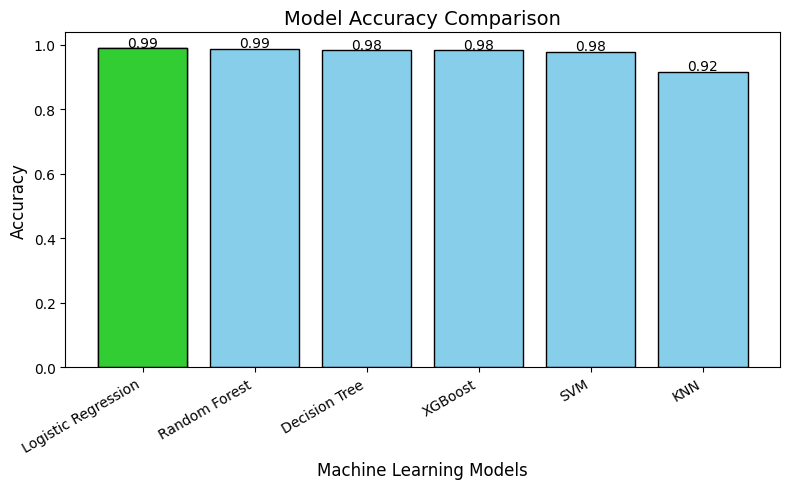


 Best Model: Logistic Regression with Accuracy = 0.9883


In [38]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue', edgecolor='black')
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=30, ha='right')

# Highlight best model
best_model = results_df.iloc[0]
plt.bar(best_model['Model'], best_model['Accuracy'], color='limegreen', edgecolor='black')

# Annotate accuracy values on top of bars
for i, row in results_df.iterrows():
    plt.text(i, row['Accuracy'] + 0.005, f"{row['Accuracy']:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n Best Model: {best_model['Model']} with Accuracy = {best_model['Accuracy']:.4f}")